<a href="https://colab.research.google.com/github/Rashed17a/MScFE-610-Financial-Econometrics/blob/main/Project_2/FE_GWP2_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autocorrelation

### Definition

Autocorrelation is used to measure the correlation of the time series with the similar time series shifted by k-lags. The autocorrelation at lag k, given a time series Xt, can also be expressed mathematically as:
![image.png](attachment:image.png)

Where:\
ρk: Autocorrelation at lag k\
X': Mean of the series Xt\
T: Number of observations


### Description

Autocorrelation is the correlation of a time series with its past or lagged values. If you are working on a time series, this is an important concept since it detects patterns, persistence, and dependencies in the data over time.

* Positive Autocorrelation: When the values of the series tend to be alike or in the same direction. In other words, in a stock or financial market, if the price of a stock is rallying today and continues to go up tomorrow, it is bullish momentum that reflects positive autocorrelation.
* Negative Autocorrelation: When values tend to go in opposite directions. For example, negative autocorrelation means that when the price of a stock goes up today, it will go down tomorrow.
Autocorrelation matters because it provides information about how the data is structured internally:
* Identifying Trend: Detects whether past values have an important impact on current values, which is crucial in predictive modelling.
* Pattern Recognition: Points out cyclical patterns or seasonality of time series data, for example, demand for products during holidays;
Nevertheless, autocorrelation stymies statistical modeling. For example:
* Autocorrelation challenges the assumption of independence in residuals in linear regression, which results in biased standard errors, ultimately risking the length hypothesis test.
* Ignoring autocorrelation in time series forecasting creates incorrect predictions.


### Demonstration

In our example, we used daily stock returns from Nvidia to illustrate autocorrelation.

**Daily Returns Calculation:** The percentage change in adjusted closing prices of Nvidia stock is calculated to evaluate daily performance.

**ACF Plot:** The plot visualizes the autocorrelation of Nvidia's daily returns over 20 lags, helping detect patterns or randomness in the time series.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Fetch Nvidia stock data
nvidia = yf.download('NVDA', start='2023-01-01', end='2024-01-01')

# Calculate daily returns
nvidia['Daily Returns'] = nvidia['Close'].pct_change()
nvidia.dropna(inplace=True)

/tmp/ipykernel_284/2890882450.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvidia = yf.download('NVDA', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


### Diagram
We can also create an ACF plot to plot the autocorrelation of Nvidia's daily returns at lags. Lag 0 is 1 (it has a perfect correlation), which makes sense. All but the first few lags have a correlation around zero and fall within the confidence interval, so we have little or no significant autocorrelation. This also implies that the past returns of Nvidia are like a fair random walk, and this is in line with the efficient market hypothesis, where the past return has very little predictive power of future returns. The absence of notable patterns implies that more advanced modeling techniques may not gain the predictive advantage, as the data lacks memory and behaves independently over time.


<Figure size 1000x600 with 0 Axes>

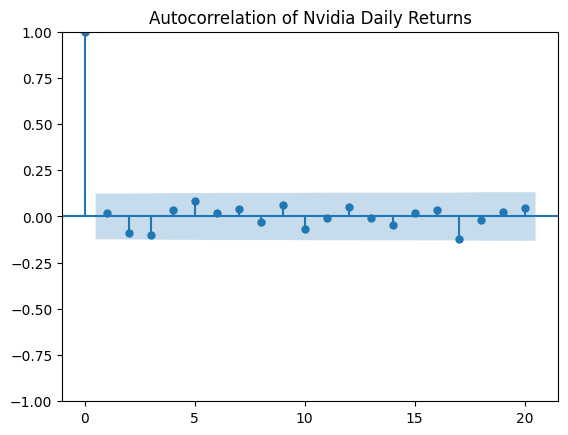

In [ ]:
# Plot ACF
plt.figure(figsize=(10, 6))
plot_acf(nvidia['Daily Returns'], lags=20, title="Autocorrelation of Nvidia Daily Returns")
plt.show()

**Residuals:** The difference between the actual daily returns and their mean is used as an example of residuals.

**Durbin-Watson Statistic:** The test statistic checks for autocorrelation in residuals:
* Values close to 2 indicate no autocorrelation.
* Values less than 2 suggest positive autocorrelation.
* Values greater than 2 suggest negative autocorrelation.

In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Residuals for example
residuals = nvidia['Daily Returns'] - nvidia['Daily Returns'].mean()
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")

Durbin-Watson Statistic: 1.9572


**Differencing:**
* Removes trends or seasonality in time series data, making it stationary.
* The first-order differenced returns are calculated by subtracting consecutive daily returns.

**Autocorrelation Function (ACF):**
* Measures the correlation between a time series and its lagged values.
* Used to assess the reduction in autocorrelation after differencing.

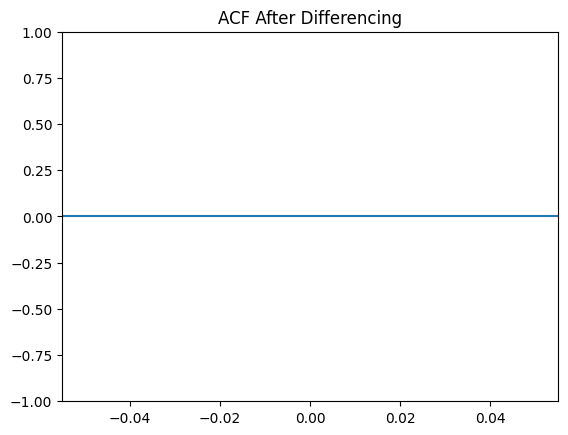

In [ ]:
# Calculate differenced returns
nvidia['Differenced Returns'] = nvidia['Daily Returns'].diff().dropna()
# Plot ACF after differencing
plot_acf(nvidia['Differenced Returns'], lags=20, title="ACF After Differencing")
plt.show()

**ARIMA Model:**

* ARIMA(p, d, q):
1. p=1: Captures first-order autocorrelation.
2. d=1: Differencing to achieve stationarity.
3. q=0: No moving average component in this example.
* Models the relationship between a time series' past values and its residuals.

**Model Summary:**
* Provides coefficients, significance tests, and fit statistics for the ARIMA model.
* Includes metrics like AIC and BIC for model selection.

**Residual Analysis:**

* Residuals represent the portion of the time series not explained by the model.
* The ACF plot of residuals helps identify remaining patterns or autocorrelation.
* Ideally, residuals should appear uncorrelated (white noise).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Daily Returns   No. Observations:                  249
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 457.121
Date:                Fri, 06 Mar 2026   AIC                           -910.242
Time:                        18:51:40   BIC                           -903.215
Sample:                             0   HQIC                          -907.413
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4409      0.035    -12.623      0.000      -0.509      -0.372
sigma2         0.0015   5.93e-05     24.702      0.000       0.001       0.002
Ljung-Box (L1) (Q):                   4.70   Jarque-

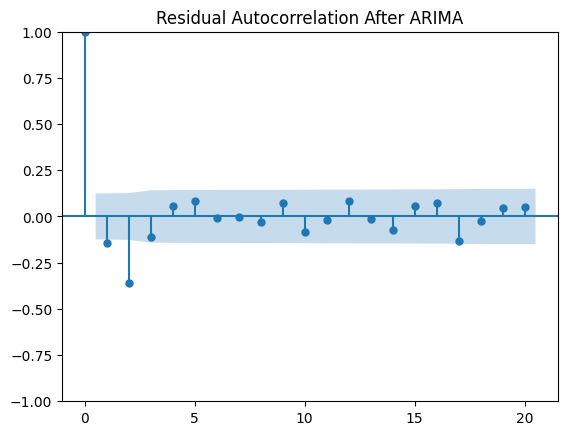

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (order p=1, d=1, q=0 to capture autocorrelation and differencing)
model = ARIMA(nvidia['Daily Returns'], order=(1, 1, 0))
arima_result = model.fit()

# Summary of the model
print(arima_result.summary())

# Plotting the residuals of the ARIMA model to check for autocorrelation
plot_acf(arima_result.resid, lags=20, title="Residual Autocorrelation After ARIMA")
plt.show()

### Diagnosis

Tests and Indicators:
* Significant Peaks as depicted in Visual ACF Plot outside confidence bounds
* Durbin-Watson Test: Tests for autocorrelation in residuals, e.g., in regression.

### Damage

* Autocorrelation can skew forecasts and statistical inferences, resulting in the overestimation or underestimation of future values.
* The assumption of independence is critical in regression models.

### Directions

* Differencing: Removes autocorrelation by transforming the series: Xt−Xt−1.
* ARIMA Models: Captures and models autocorrelation explicitly.

# Heteroskedasticity

### Definition
Heteroskedasticity is when the standard deviations of a predicted variable, monitored over different values of an independent variable or as related to prior time periods, are non-constant.

### Description

Heteroskedasticity : In time series model the common structure  of linear model is
![image.png](attachment:image.png)
and it goes with common gauss - markov assumption  where error  has   zero mean and it has constant variance as well as uncorrelated and it is normally distributed .


When error has constant variance then we have what is called homoscedasticity and when the variance of  error as well as residual term changes  with time it is known as heteroskedasticity and it is given by
Var(ϵi​)=σ2∀i (IIT Kanpur and Shalabh)


### Demonstration

In [ ]:
!pip install arch
!pip install copulas
import statsmodels.api as sm
import statsmodels.stats.api as sms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from arch import arch_model
from copulas.multivariate import GaussianMultivariate
import warnings

# Step 1: Simulate data with more drastic heteroskedasticity
np.random.seed(42)

# Define true parameters
intercept_true = 3
slope_true = -2

# Generate the independent variable (X)
n = 500  # Increase sample size to 500
X = np.linspace(-5, 5, n)

# Generate the heteroskedastic error term with more pronounced heteroskedasticity
# Increased noise variance: noise variance depends more strongly on X^6
noise = np.random.normal(0, 1 + 5 * X**6, n)

# Generate the dependent variable (Y)
Y = intercept_true + slope_true * X + noise

# Step 2: Fit OLS model
X_with_intercept = sm.add_constant(X)  # Add constant for intercept
ols_model = sm.OLS(Y, X_with_intercept)
ols_results = ols_model.fit()

# Step 3: Calculate the true standard errors
true_variance_intercept = np.std(noise)**2 / n
true_variance_slope = np.std(noise)**2 / np.var(X)
true_se_intercept = np.sqrt(true_variance_intercept)
true_se_slope = np.sqrt(true_variance_slope)

# Step 4: Calculate the OLS standard errors
ols_se_intercept = ols_results.bse[0]
ols_se_slope = ols_results.bse[1]

# Step 5: Perform Breusch-Pagan test for heteroskedasticity
bp_test = sms.het_breuschpagan(ols_results.resid, ols_results.model.exog)

# Step 6: Perform White’s test for heteroskedasticity (robust to heteroskedasticity)
white_test = sms.het_white(ols_results.resid, ols_results.model.exog)

# Step 7: Print results
print(f"Average OLS standard error for intercept: {ols_se_intercept:.4f}")
print(f"Average OLS standard error for slope: {ols_se_slope:.4f}")
print(f"True standard error for intercept: {true_se_intercept:.4f}")
print(f"True standard error for slope: {true_se_slope:.4f}")

print(f"\nBreusch-Pagan test result: {bp_test[1]:.4f}")
if bp_test[1] < 0.05:
    print("There is significant evidence of heteroskedasticity.")
else:
    print("No significant evidence of heteroskedasticity.")

print(f"\nWhite's test result: {white_test[1]:.4f}")
if white_test[1] < 0.05:
    print("White's test: Significant evidence of heteroskedasticity.")
else:
    print("White's test: No significant evidence of heteroskedasticity.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.5 MB/s eta 0:00:00
Average OLS standard error for intercept: 985.5614
Average OLS standard error for slope: 340.7263
True standard error for intercept: 983.6688
True standard error for slope: 7604.2422

Breusch-Pagan test result: 0.0974
No significant evidence of heteroskedasticity.

White's test result: 0.0000
White's test: Significant evidence of heteroskedasticity.


In [ ]:
# Step 1: Download the data
tickers = ["BTC-USD", "ETH-USD"]
data = yf.download(tickers, start="2017-01-01", end="2023-01-01")["Close"]

# Step 2: Calculate log returns
log_returns = np.log(data / data.shift(1)).dropna()

# Step 3: Rescale log returns to address scaling warnings
log_returns_rescaled = log_returns * 100

# Step 4: Homoskedastic Portfolio Optimization
cov_matrix = log_returns.cov()
weights_homo = np.linalg.inv(cov_matrix).dot(np.ones(len(tickers)))
weights_homo /= np.sum(weights_homo)

# Portfolio volatility under homoskedastic assumption
portfolio_vol_homo = np.sqrt(weights_homo.T.dot(cov_matrix).dot(weights_homo))

# Value at Risk (VaR) - Homoskedastic
VaR_homo = -np.percentile(log_returns.dot(weights_homo), 1)  # 99% confidence level

# Sharpe Ratio (Homoskedastic)
sharpe_ratio_homo = log_returns.mean().dot(weights_homo) / portfolio_vol_homo

# Step 5: Heteroskedastic Portfolio Optimization using GARCH(1,1)
volatility_btc = arch_model(log_returns_rescaled["BTC-USD"], vol="Garch", p=1, q=1).fit(disp="off").conditional_volatility
volatility_eth = arch_model(log_returns_rescaled["ETH-USD"], vol="Garch", p=1, q=1).fit(disp="off").conditional_volatility

volatility_matrix = np.vstack([volatility_btc, volatility_eth]).T / 100
weights_hetero = np.linalg.inv(np.cov(volatility_matrix.T)).dot(np.ones(len(tickers)))
weights_hetero /= np.sum(weights_hetero)


# Sharpe Ratio (Heteroskedastic)
portfolio_vol_hetero = np.sqrt(weights_hetero.T.dot(cov_matrix).dot(weights_hetero))
sharpe_ratio_hetero = log_returns.mean().dot(weights_hetero) / portfolio_vol_hetero

# Step 7: Print Results
print(f"Optimized Portfolio Weights (Homoskedastic): {weights_homo}")
print(f"Optimized Portfolio Weights (Heteroskedastic): {weights_hetero}")
print(f"Portfolio Volatility (Homoskedastic): {portfolio_vol_homo}")
print(f"Portfolio Volatility (Heteroskedastic): {portfolio_vol_hetero}")
print(f"Sharpe Ratio (Homoskedastic): {sharpe_ratio_homo}")
print(f"Sharpe Ratio (Heteroskedastic): {sharpe_ratio_hetero}")


/tmp/ipykernel_284/2878075670.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2017-01-01", end="2023-01-01")["Close"]
[*********************100%***********************]  2 of 2 completed

Optimized Portfolio Weights (Homoskedastic): [ 1.01232155 -0.01232155]
Optimized Portfolio Weights (Heteroskedastic): [0.80097614 0.19902386]
Portfolio Volatility (Homoskedastic): 0.04030247307017131
Portfolio Volatility (Heteroskedastic): 0.04084810796526051
Sharpe Ratio (Homoskedastic): 0.011020924173063011
Sharpe Ratio (Heteroskedastic): 0.012185878960814946


In [ ]:
# Download Tesla and S&P 500 data
tesla = yf.download('TSLA', start='2010-01-01', end='2024-12-01')
sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-12-01')

# Calculate daily returns
tesla['Returns'] = tesla['Close'].pct_change() * 100
if isinstance(tesla.columns, pd.MultiIndex): tesla.columns = tesla.columns.get_level_values(0)
if isinstance(sp500.columns, pd.MultiIndex): sp500.columns = sp500.columns.get_level_values(0)
sp500['Returns'] = sp500['Close'].pct_change() * 100

# Drop missing values
tesla.dropna(subset=['Returns'], inplace=True)
sp500.dropna(subset=['Returns'], inplace=True)

# GARCH Model (Generalized Autoregressive Conditional Heteroskedasticity)
model = arch_model(tesla['Returns'], vol='Garch', p=1, q=1)
garch_result = model.fit()

# GARCH Model Results
print(garch_result.summary())

# Extreme Value Theory (EVT)
# Extract extreme values from the tail (1% worst returns)
threshold = np.percentile(tesla['Returns'], 1)
extreme_values = tesla[tesla['Returns'] <= threshold]['Returns']

# Fit the Generalized Extreme Value (GEV) distribution
try:
    gev_params = stats.genextreme.fit(extreme_values)
    print(f"GEV Parameters: {gev_params}")

    # Calculate the 99th percentile (extreme quantile)
    extreme_quantile_99 = stats.genextreme.ppf(0.99, *gev_params)
    print(f"99th percentile extreme quantile for Tesla returns: {extreme_quantile_99}")

except Exception as e:
    print(f"Error fitting GEV: {e}")

# Additional analysis using EVT
# For visualization or further analysis, you can consider using copulas to capture dependencies
# between Tesla returns and S&P 500, but that requires further steps and libraries.
# Since 'copulas' library was giving an error, consider visualizing the copula relationship later.

# For now, you can plot the returns to observe the distribution


# Handle any warnings related to fitting
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in')


/tmp/ipykernel_284/95846000.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla = yf.download('TSLA', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_284/95846000.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed

Iteration:      1,   Func. Count:      6,   Neg. LLF: 24708.17775786332
Iteration:      2,   Func. Count:     15,   Neg. LLF: 25540.978772669456
Iteration:      3,   Func. Count:     23,   Neg. LLF: 20321.37765902812
Iteration:      4,   Func. Count:     31,   Neg. LLF: 9691.936345102811
Iteration:      5,   Func. Count:     37,   Neg. LLF: 9825.879414378822
Iteration:      6,   Func. Count:     43,   Neg. LLF: 9683.544634460242
Iteration:      7,   Func. Count:     49,   Neg. LLF: 9662.821328292308
Iteration:      8,   Func. Count:     55,   Neg. LLF: 9654.928430397384
Iteration:      9,   Func. Count:     61,   Neg. LLF: 9660.11490093141
Iteration:     10,   Func. Count:     67,   Neg. LLF: 9639.351204044844
Iteration:     11,   Func. Count:     73,   Neg. LLF: 10725.703054594833
Iteration:     12,   Func. Count:     79,   Neg. LLF: 9640.21515388565
Iteration:     13,   Func. Count:     85,   Neg. LLF: 9628.20789514264
Iteration:     14,   Func. Count:     91,   Neg. LLF: 9627.922758

/tmp/ipykernel_284/2275730118.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla = yf.download('TSLA', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_284/2275730118.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-12-01')
[*********************100%***********************]  1 of 1 completed


Tesla Returns Normality Test (Jarque-Bera):
Statistic: 3794.3295108416705, p-value: 0.0

S&P 500 Returns Normality Test (Jarque-Bera):
Statistic: 23646.37105677709, p-value: 0.0
Tesla returns are not normally distributed (reject normality).
S&P 500 returns are not normally distributed (reject normality).
Iteration:      1,   Func. Count:      6,   Neg. LLF: 24708.17775786332
Iteration:      2,   Func. Count:     15,   Neg. LLF: 25540.978772669456
Iteration:      3,   Func. Count:     23,   Neg. LLF: 20321.37765902812
Iteration:      4,   Func. Count:     31,   Neg. LLF: 9691.936345102811
Iteration:      5,   Func. Count:     37,   Neg. LLF: 9825.879414378822
Iteration:      6,   Func. Count:     43,   Neg. LLF: 9683.544634460242
Iteration:      7,   Func. Count:     49,   Neg. LLF: 9662.821328292308
Iteration:      8,   Func. Count:     55,   Neg. LLF: 9654.928430397384
Iteration:      9,   Func. Count:     61,   Neg. LLF: 9660.11490093141
Iteration:     10,   Func. Count:     67,   Ne

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6738: RuntimeWarning: divide by zero encountered in power
  return cd2*x**(c-1)


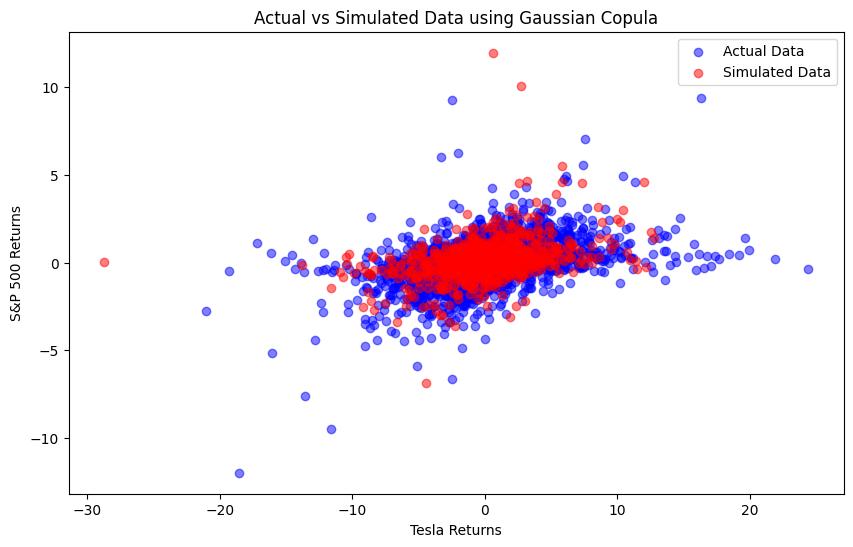

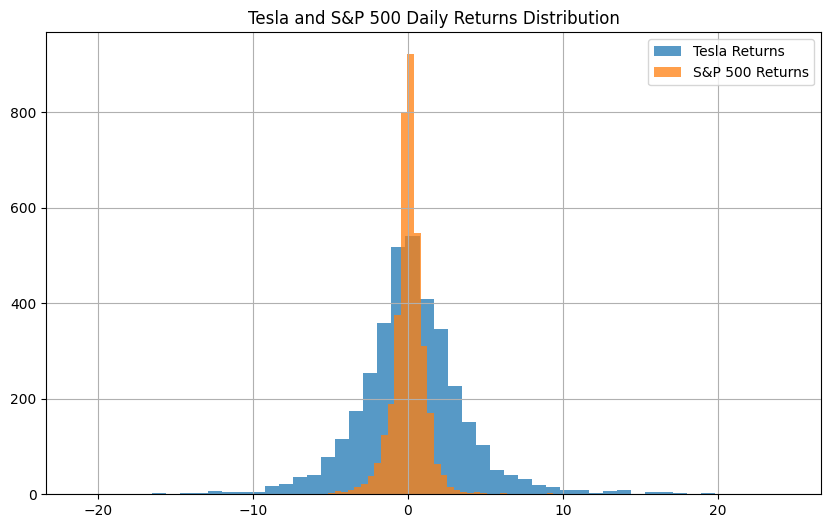

In [ ]:
from scipy import stats
# Download Tesla and S&P 500 data
tesla = yf.download('TSLA', start='2010-01-01', end='2024-12-01')
sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-12-01')

if isinstance(tesla.columns, pd.MultiIndex): tesla.columns = tesla.columns.get_level_values(0)
if isinstance(sp500.columns, pd.MultiIndex): sp500.columns = sp500.columns.get_level_values(0)
# Calculate daily returns
tesla['Returns'] = tesla['Close'].pct_change() * 100
sp500['Returns'] = sp500['Close'].pct_change() * 100

# Drop missing values
tesla.dropna(subset=['Returns'], inplace=True)
sp500.dropna(subset=['Returns'], inplace=True)

# Step 1: Normality Test (Jarque-Bera Test)
tesla_jb_stat, tesla_jb_p_value = stats.jarque_bera(tesla['Returns'])
sp500_jb_stat, sp500_jb_p_value = stats.jarque_bera(sp500['Returns'])

# Print the results of the normality tests
print("Tesla Returns Normality Test (Jarque-Bera):")
print(f"Statistic: {tesla_jb_stat}, p-value: {tesla_jb_p_value}")
print("\nS&P 500 Returns Normality Test (Jarque-Bera):")
print(f"Statistic: {sp500_jb_stat}, p-value: {sp500_jb_p_value}")

# Interpretation of Normality Test Results
if tesla_jb_p_value < 0.05:
    print("Tesla returns are not normally distributed (reject normality).")
else:
    print("Tesla returns are normally distributed.")

if sp500_jb_p_value < 0.05:
    print("S&P 500 returns are not normally distributed (reject normality).")
else:
    print("S&P 500 returns are normally distributed.")

# GARCH Model (Generalized Autoregressive Conditional Heteroskedasticity)
model = arch_model(tesla['Returns'], vol='Garch', p=1, q=1)
garch_result = model.fit()

# GARCH Model Results
print(garch_result.summary())

# Extreme Value Theory (EVT)
# Extract extreme values from the tail (1% worst returns)
threshold = np.percentile(tesla['Returns'], 1)
extreme_values = tesla[tesla['Returns'] <= threshold]['Returns']

# Fit the Generalized Extreme Value (GEV) distribution
try:
    gev_params = stats.genextreme.fit(extreme_values)
    print(f"GEV Parameters: {gev_params}")

    # Calculate the 99th percentile (extreme quantile)
    extreme_quantile_99 = stats.genextreme.ppf(0.99, *gev_params)
    print(f"99th percentile extreme quantile for Tesla returns: {extreme_quantile_99}")

except Exception as e:
    print(f"Error fitting GEV: {e}")

# Copula Model
# Step 2: Fit Gaussian Copula
returns_data = pd.concat([tesla['Returns'], sp500['Returns']], axis=1)
returns_data.columns = ['Tesla Returns', 'S&P 500 Returns']

# Ensure no NaN values in returns_data before fitting copula
returns_data = returns_data.dropna()

# Step 3: Fit Gaussian Copula
copula = GaussianMultivariate()
copula.fit(returns_data)

# Step 4: Simulate data using the copula
simulated_data = copula.sample(1000)  # Simulate 1000 data points

# Visualizing the simulated data vs actual data
plt.figure(figsize=(10, 6))

# Plot actual returns
plt.scatter(returns_data['Tesla Returns'], returns_data['S&P 500 Returns'], color='blue', alpha=0.5, label='Actual Data')

# Plot simulated data
plt.scatter(simulated_data['Tesla Returns'], simulated_data['S&P 500 Returns'], color='red', alpha=0.5, label='Simulated Data')

plt.legend()
plt.title('Actual vs Simulated Data using Gaussian Copula')
plt.xlabel('Tesla Returns')
plt.ylabel('S&P 500 Returns')
plt.show()

# Additional analysis using EVT
# For visualization or further analysis, you can consider using copulas to capture dependencies
# between Tesla returns and S&P 500.

# For now, you can plot the returns to observe the distribution
plt.figure(figsize=(10, 6))
tesla['Returns'].hist(bins=50, alpha=0.75, label='Tesla Returns')
sp500['Returns'].hist(bins=50, alpha=0.75, label='S&P 500 Returns')
plt.legend()
plt.title('Tesla and S&P 500 Daily Returns Distribution')
plt.show()

# Handle any warnings related to fitting
warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in')


### Diagram

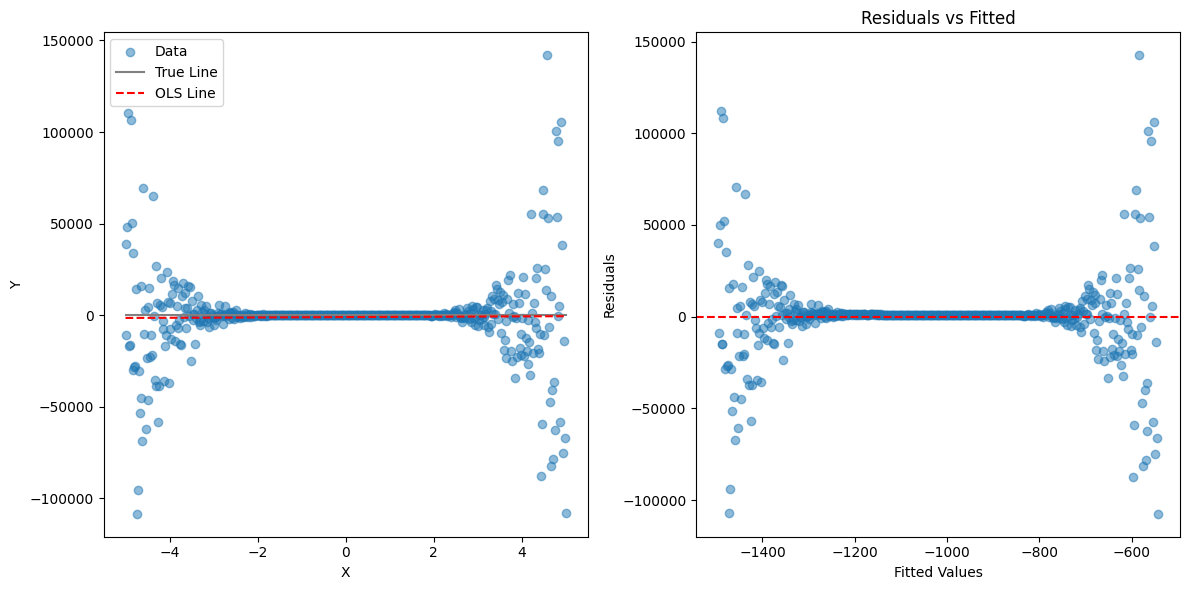

In [ ]:
# Plot the data and residuals
plt.figure(figsize=(12, 6))

# Scatter plot for data
plt.subplot(1, 2, 1)
plt.scatter(X, Y, label="Data", alpha=0.5)
plt.plot(X, intercept_true + slope_true * X, color="grey", label="True Line")
plt.plot(X, ols_results.fittedvalues, linestyle="--", color="red", label="OLS Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

# Residuals vs Fitted plot
plt.subplot(1, 2, 2)
plt.scatter(ols_results.fittedvalues, ols_results.resid, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.tight_layout()
plt.show()

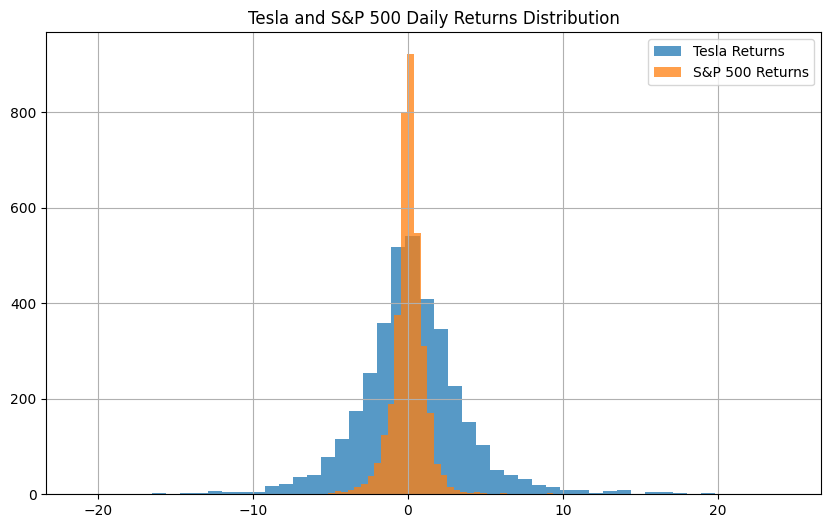

In [ ]:
plt.figure(figsize=(10, 6))
tesla['Returns'].hist(bins=50, alpha=0.75, label='Tesla Returns')
sp500['Returns'].hist(bins=50, alpha=0.75, label='S&P 500 Returns')
plt.legend()
plt.title('Tesla and S&P 500 Daily Returns Distribution')
plt.show()

### Diagnosis

The heteroskedasticity is  found through several statistical tests available:
* Breusch Pagan test:  This is done when variance is taken as a function of  greater than one variables basically the explanatory variables
* Goldfeld Quandt test: This is done when any one of the variables explain the heteroskedasticity
* White test : This is done whether variance depends upon explanatory variables using cross product and their squares.


### Damage

Heteroskedasticity leads to:
1. Inefficient parameter estimates
2. Incorrect risk assessments
3. Unreliable Value at Risk (VaR) calculations
4. Poor portfolio optimization decision    Some of them have been shown in the code


### Directions

* ARCH family models for volatility clustering
* Robust standard errors for inference (Shalizi) (have been shown in the impact of heteroskedasticity python code)
* Rolling window volatility estimation implementation_steps
* Test for ARCH effects',
* Select appropriate GARCH specification
* Validate model assumptions
* Implement volatility forecasting


# Over-reliance on normality

### Definition
Normal and non-normal distributions are fundamental concepts in statistics that describe different patterns of data distribution. Normal distribution allows for straightforward statistical analysis and prediction.. Non-normal distributions can exhibit various shapes and characteristics, making them more complex to analyze. The difference between normal and non-normal distributions is essential for analyzing data accurately. (https://www.geeksforgeeks.org/normal-vs-non-normal-distribution/)
Assuming normal distribution without proper analysis can lead to poor statistical results and harm one's judgement.



Normal distribution probability density function:

$$ f(X) = \frac{1}{\sigma_{_{X}} \sqrt{2\pi }} e^{-\frac{1}{2} \left( \frac{X-\mu_{_{X}}}{\sigma_{{X}}} \right)^{2}} $$

Where $-\infty < X < \infty $


### Description

To achieve correct assumptions one should test normality on the data, to do so, we can turn to different methods, mainly graphs (visual) and statistical (numerical) tests.

##### The hypothesis in normality test:

H0: The data follows a normal distribution. \
H1: The data does not follow a normal distribution.

Statistical Tests:
1. Kolmogorov-Smirnov Test
2. Shaprio-Wilk Test

Graphs:
1. QQ Plot
2. Boxplot
3. Distribution Histogram



### Demonstration


In [ ]:
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from scipy.stats import ks_1samp, norm

In [ ]:
df_data = pd.DataFrame()
tickers = ['NVDA','INTC', 'AAPL', 'AMD', 'SMCI', 'AMZN', 'BTC-USD', 'XOM']
for ticker in tickers:
    df_data[ticker] = yfin.download([ticker], '2014-11-01','2024-11-01')["Close"].pct_change()
df_data.fillna(method='bfill',inplace=True)
df_data.tail()

/tmp/ipykernel_284/2500601497.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download([ticker], '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_284/2500601497.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download([ticker], '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_284/2500601497.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download([ticker], '2014-11-01','2024-11-01')["Close"].pct_change()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_284/2500601497.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_data[ticker] = yfin.download([ticker], '2014-11-01','

,NVDA,INTC,AAPL,AMD,SMCI,AMZN,BTC-USD,XOM
Date,,,,,,,,
2024-10-25,0.008048,0.015219,0.003643,0.018183,0.022496,0.007780,-0.022280,-0.000836
2024-10-28,-0.007206,0.010582,0.008599,0.023619,0.009520,0.002981,0.029125,-0.004938
2024-10-29,0.005195,-0.000873,0.001157,0.039582,0.029338,0.012952,0.040235,-0.013625
2024-10-30,-0.013522,-0.026201,-0.015278,-0.106165,-0.326751,0.009956,-0.005239,-0.005031
2024-10-31,-0.047223,-0.034978,-0.018210,-0.030485,-0.119746,-0.032844,-0.029366,0.000771


In [ ]:
test_results =[]

for ticker in tickers:
    mean = df_data[ticker].mean()
    std = df_data[ticker].std()
    statistic, p_value = ks_1samp(df_data[ticker], cdf=lambda x: norm.cdf(x, loc=mean, scale=std))
    test_results.append({
        'Ticker': ticker,
        'KS Statistic': round(statistic,4),
        'P-Value': round(p_value,4),
        'Normality': 'Yes' if p_value > 0.05 else 'No'
    })

print(pd.DataFrame(test_results))

    Ticker  KS Statistic  P-Value Normality
0     NVDA        0.0694      0.0        No
1     INTC        0.0816      0.0        No
2     AAPL        0.0748      0.0        No
3      AMD        0.0708      0.0        No
4     SMCI        0.1157      0.0        No
5     AMZN        0.0732      0.0        No
6  BTC-USD        0.0903      0.0        No
7      XOM        0.0693      0.0        No


In [ ]:
test_results =[]

for ticker in tickers:
    shapiro_test = stats.shapiro(df_data[ticker])
    test_results.append({
        'Ticker': ticker,
        'SW Statistic': round(shapiro_test.statistic,4),
        'P-Value': round(shapiro_test.pvalue,4),
        'Normality': 'Yes' if shapiro_test.pvalue > 0.05 else 'No'
    })

print(pd.DataFrame(test_results))

    Ticker  SW Statistic  P-Value Normality
0     NVDA        0.9304      0.0        No
1     INTC        0.8853      0.0        No
2     AAPL        0.9436      0.0        No
3      AMD        0.9153      0.0        No
4     SMCI        0.7950      0.0        No
5     AMZN        0.9308      0.0        No
6  BTC-USD        0.9177      0.0        No
7      XOM        0.9359      0.0        No


### Diagram

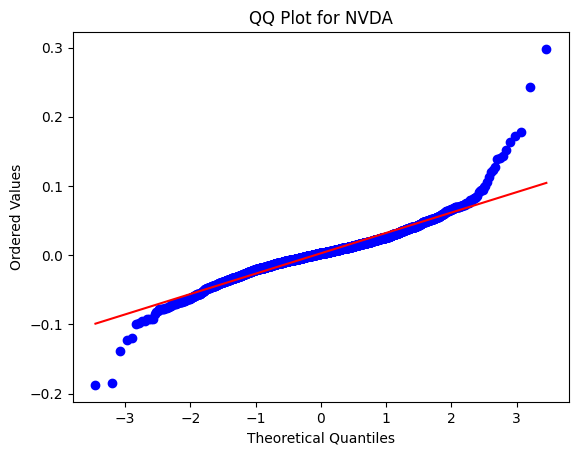

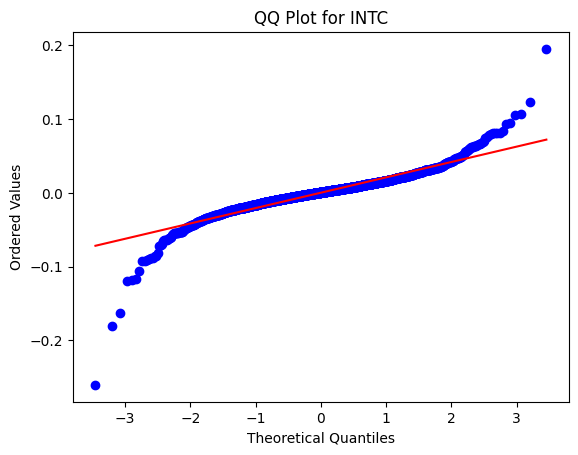

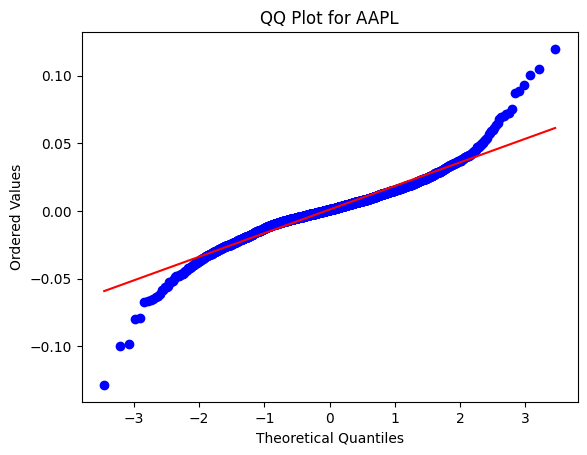

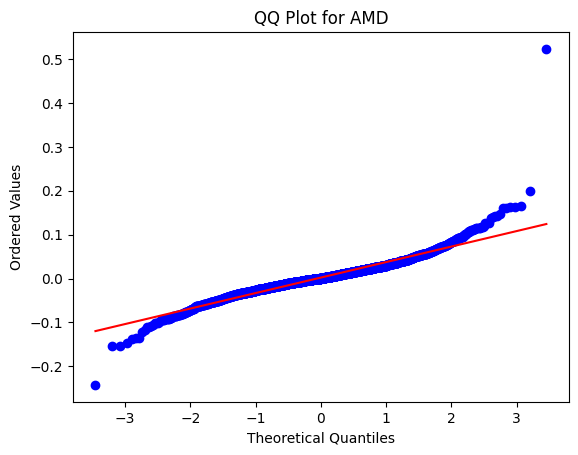

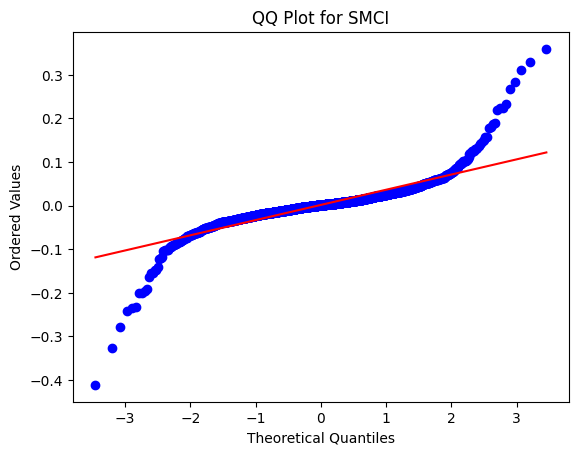

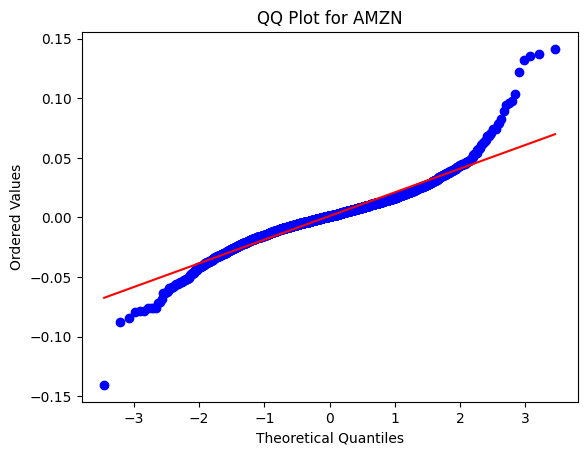

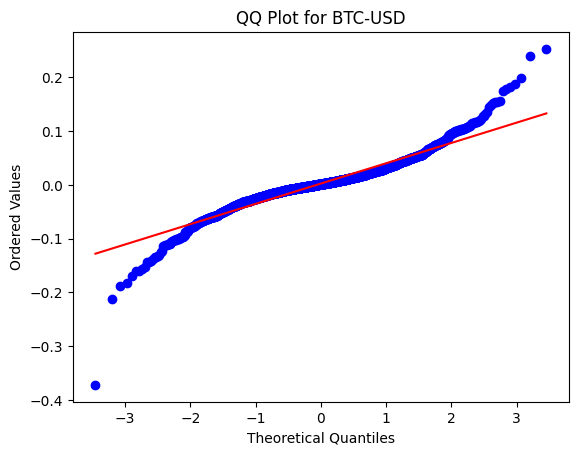

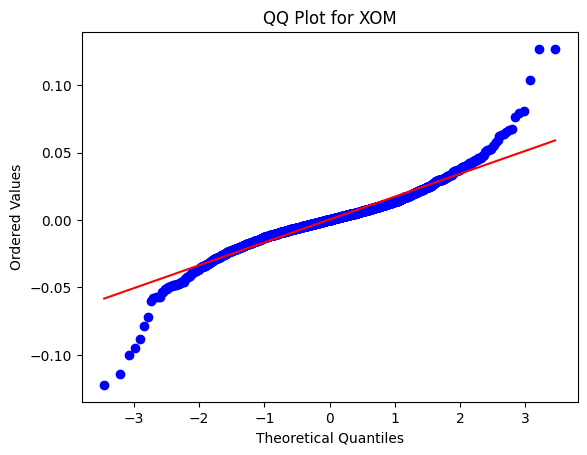

In [ ]:
for ticker in tickers:
    stats.probplot(df_data[ticker], dist="norm", plot=plt)
    plt.title(f"QQ Plot for {ticker}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Ordered Values")
    plt.show()

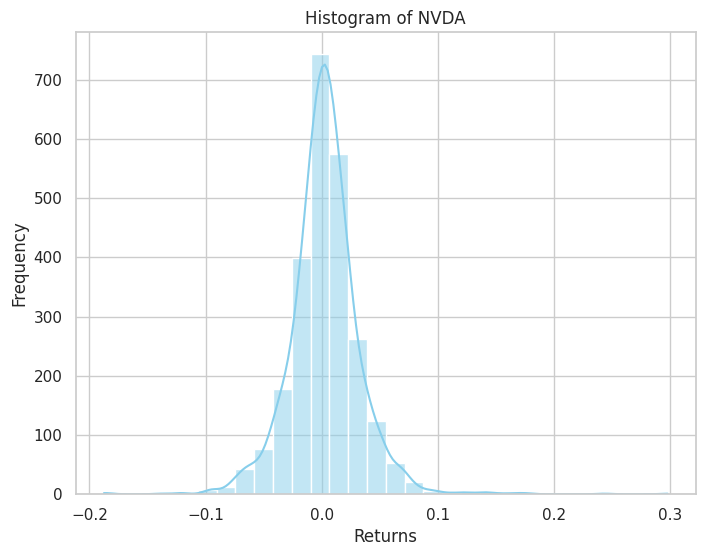

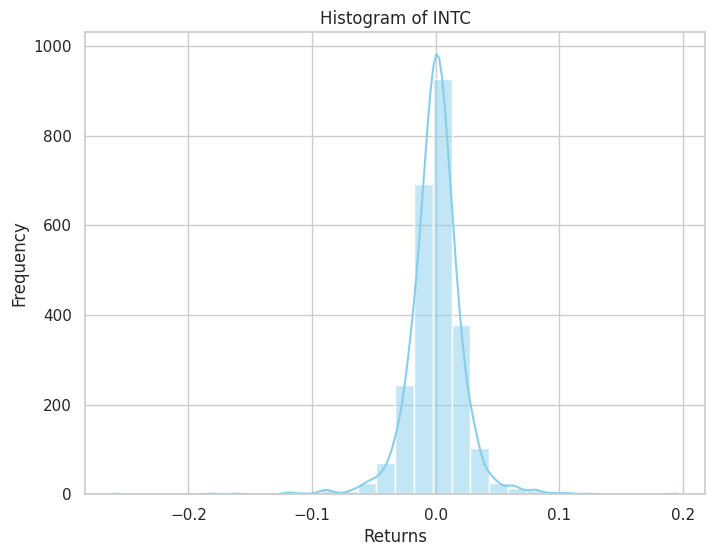

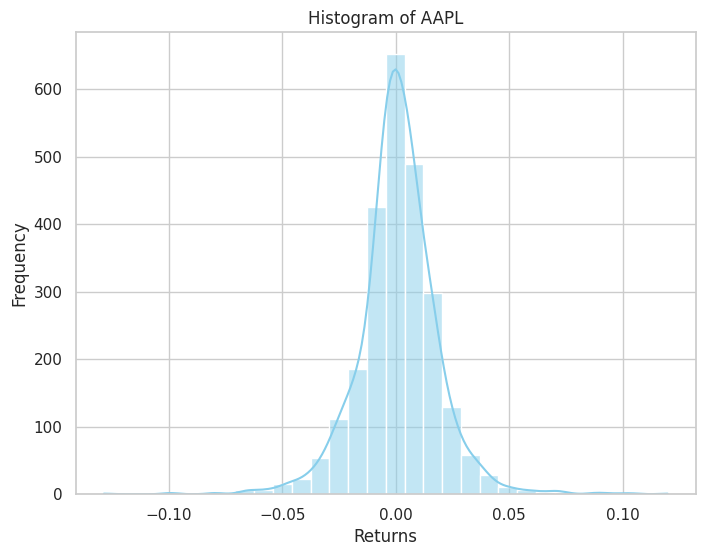

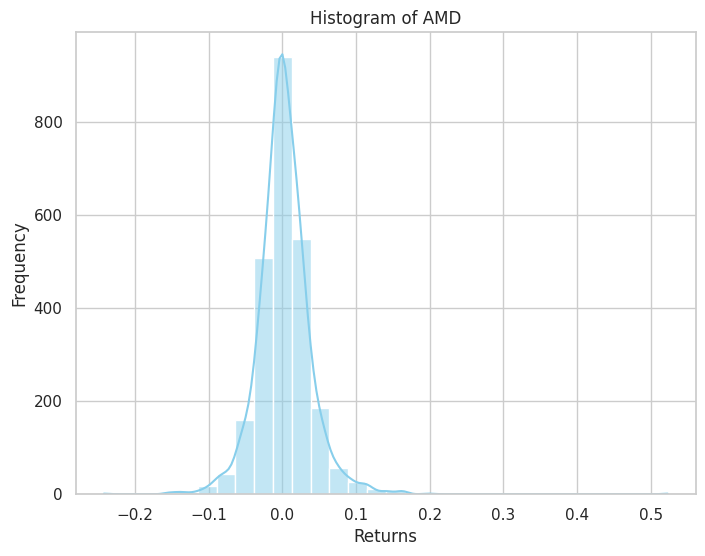

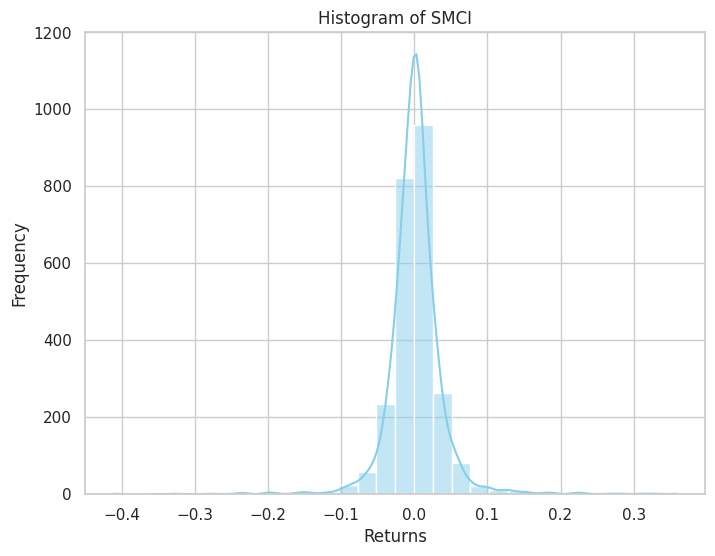

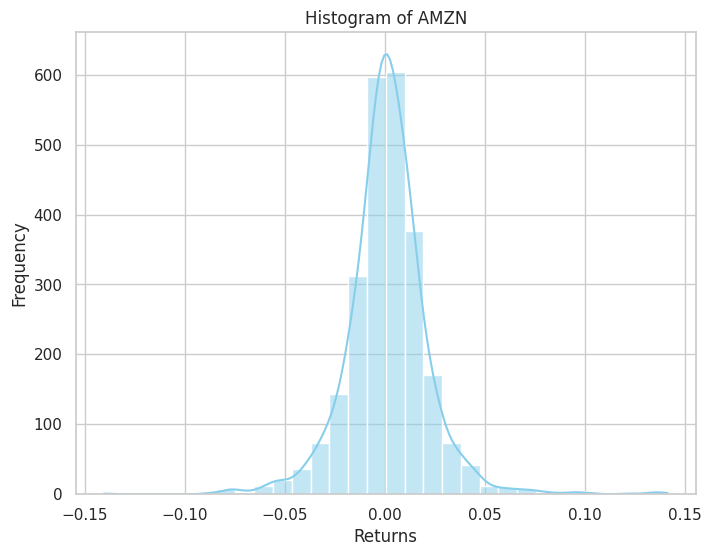

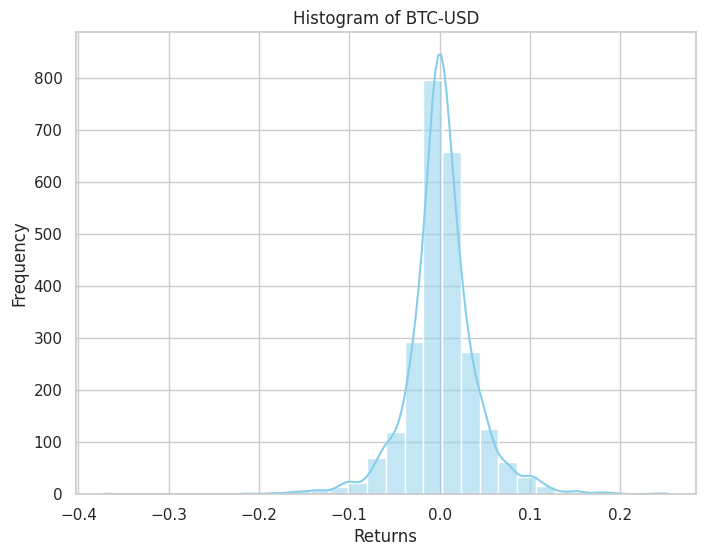

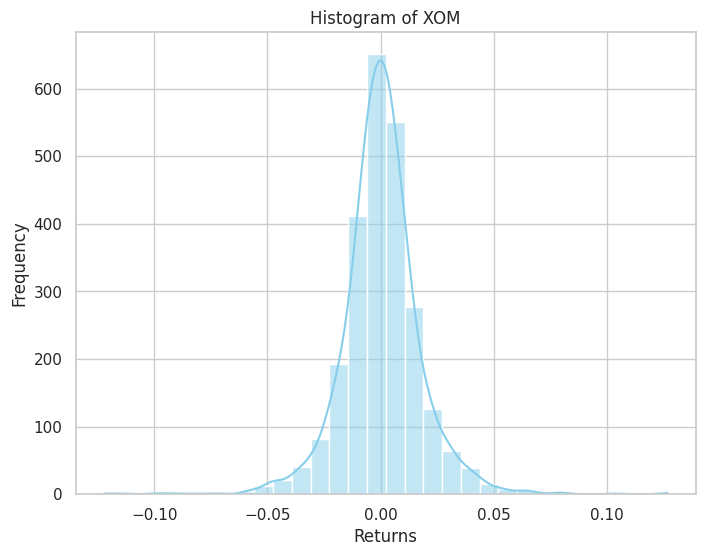

In [ ]:
for ticker in tickers:
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    sns.histplot(df_data[ticker], bins=30, kde=True, color='skyblue')
    plt.title(f"Histogram of {ticker}")
    plt.xlabel("Returns")
    plt.ylabel("Frequency")

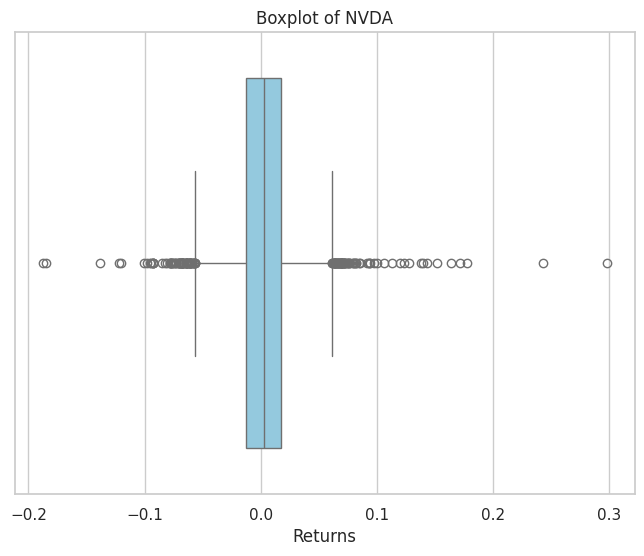

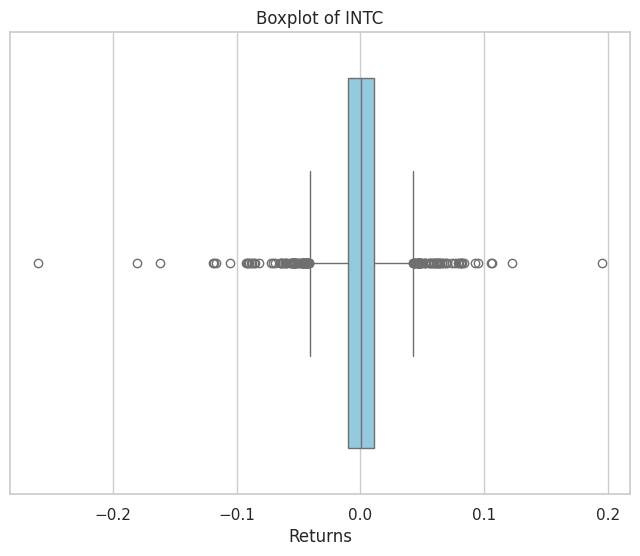

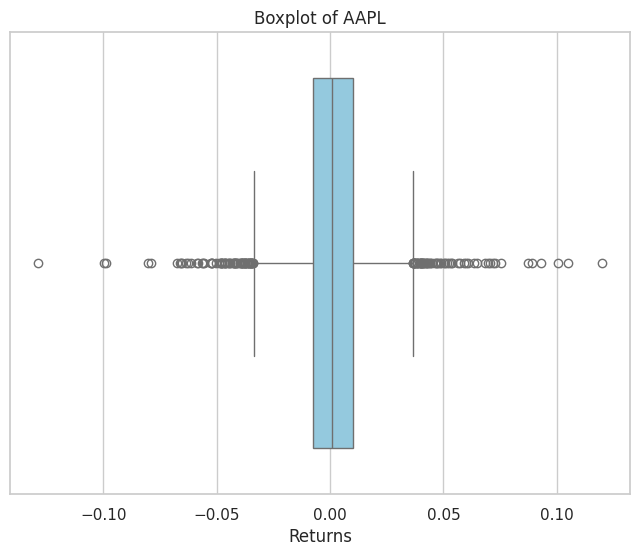

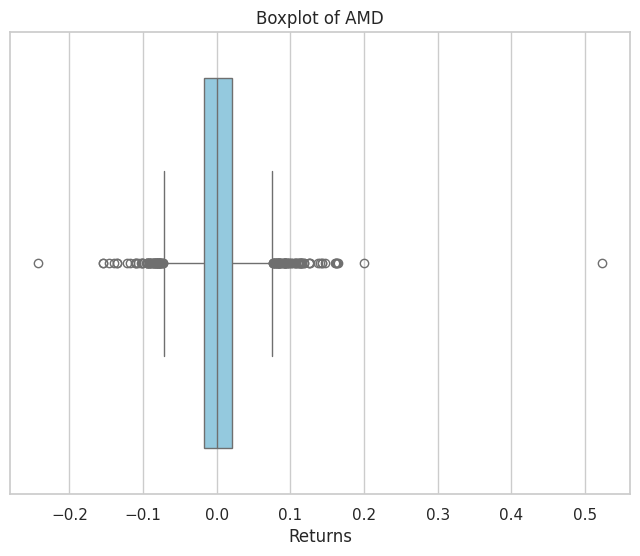

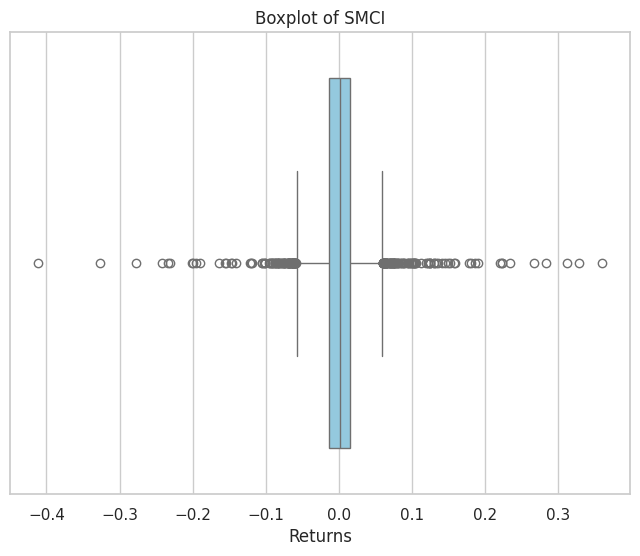

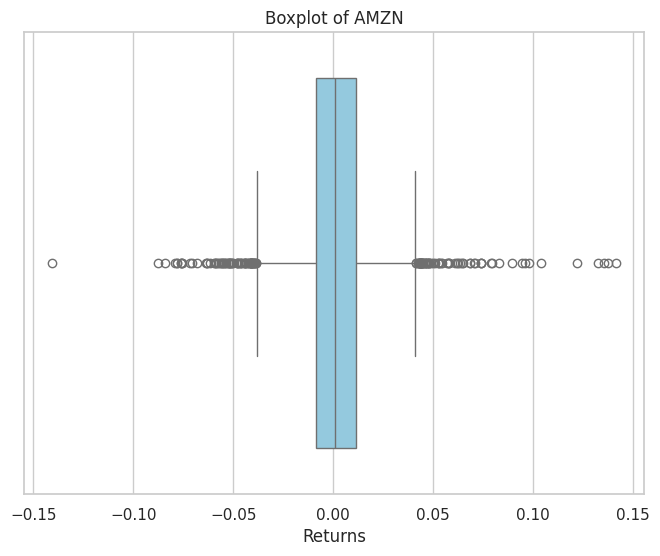

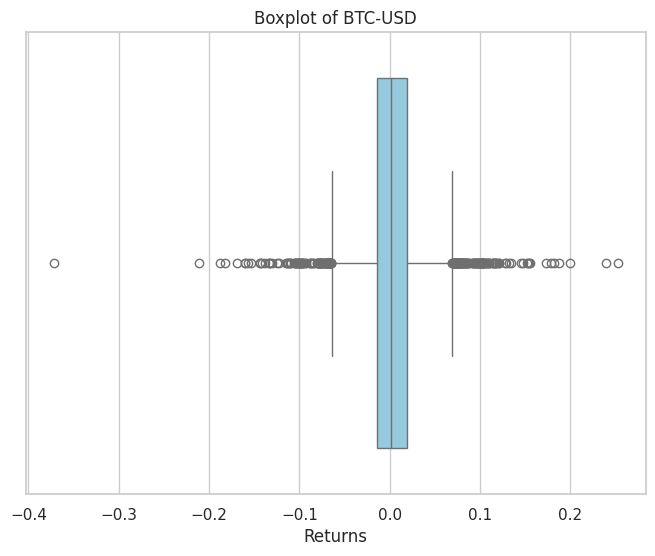

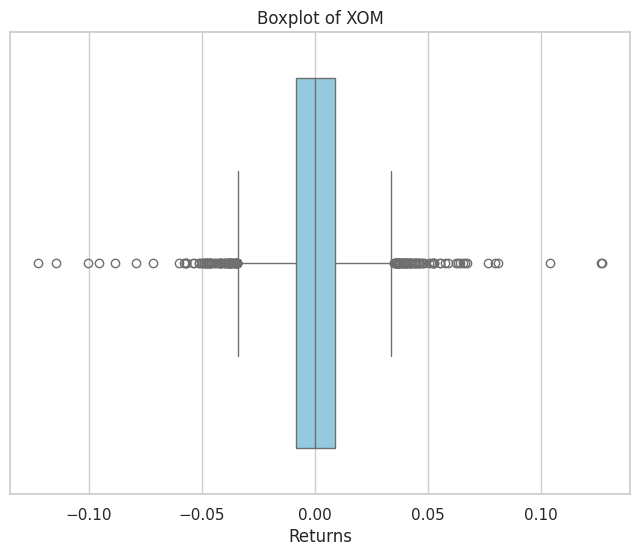

In [ ]:
for ticker in tickers:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_data[ticker], color='skyblue')
    plt.title(f"Boxplot of {ticker}")
    plt.xlabel("Returns")

### Diagnosis

The statistical tests and graph tests all lead to the same conclusion, that the returns are not normally distributed in our data. The P-values are below 0.05 for both Shapiro-Wilk and Kolmogorov-Smirnov tests. The QQ-plots suggest a heavy-tailed distribution whilst the histograms show the presence of positive kurtosis. Boxplots show the presence of many potential outliers.

### Damage

Assuming normal distribution when the data is distributed differently can affect the:
Confidence Intervals
Mean and Standard Deviation
Model Fit
Predictions


### Directions

Test for more suitable distributions to the data.
Transform data with log returns or Box-Cox transformation.


# Non-stationarity

### Definition
A time series is said to be non-stationary if its statistical properties, such as mean, variance, and autocorrelation, vary with time. Non-stationarity is an important issue when modeling time series data, since many statistical models, including ARIMA, assume the data to be stationary.\
\
Stationarity Time Series:
A time series Yt is stationary if for any point in time t, the following conditions are met (Baumöhl and Lyócsa):
![image.png](attachment:image.png)

Where:\
μ is the mean,\
σ^2 is the variance,\
γh is the autocovariance at lag h.


### Description

Non-stationarity often manifests in two ways:

1. Trend: A long-term upward or downward movement in the data.
2. Seasonality: Periodic fluctuations at regular intervals.

Non-stationarity due to, for example, trends, e.g., market growth, or volatility clustering is common in real-world financial data.

### Demonstration

In [ ]:
!pip install pmdarima
import yfinance as yf
import matplotlib.pyplot as plt
import pandas  as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima


# Download BTC data from Yahoo Finance
data = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.0 MB/s eta 0:00:00


/tmp/ipykernel_284/2458453972.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(data['Close'])
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')


ADF Statistic: -1.7427831727868728
p-value: 0.4092149282528966


In [ ]:
if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

# Log transformation
data['Log'] = np.log(data['Close'])

# Seasonal differencing (lag=7 for weekly seasonality)
data['Seasonal_Diff'] = data['Close'].diff(7)
data_seasonal_diff = data.dropna(subset=['Seasonal_Diff'])

# Log differencing
data['Log_Diff'] = data['Log'].diff(1)
data_log_diff = data.dropna(subset=['Log_Diff'])

In [ ]:
# Perform ADF test on log-transformed data
adf_result_log = adfuller(data['Log'].dropna())
print(f'ADF Statistic (Log Transformed): {adf_result_log[0]}')
print(f'p-value (Log Transformed): {adf_result_log[1]}')

ADF Statistic (Log Transformed): -1.7200910100572424
p-value (Log Transformed): 0.4207918413327777


In [ ]:
# Perform ADF test on seasonal differenced data
adf_result_seasonal_diff = adfuller(data_seasonal_diff['Seasonal_Diff'])
print(f'ADF Statistic (Seasonal Differenced): {adf_result_seasonal_diff[0]}')
print(f'p-value (Seasonal Differenced): {adf_result_seasonal_diff[1]}')


ADF Statistic (Seasonal Differenced): -5.629477512110288
p-value (Seasonal Differenced): 1.0978735304099134e-06


In [ ]:
# Perform ADF test on log-differenced data
adf_result_log_diff = adfuller(data_log_diff['Log_Diff'])
print(f'ADF Statistic (Log Differenced): {adf_result_log_diff[0]}')
print(f'p-value (Log Differenced): {adf_result_log_diff[1]}')


ADF Statistic (Log Differenced): -12.34049302926106
p-value (Log Differenced): 6.134306757250108e-23


In [ ]:
# Assuming `data` is the DataFrame containing the Bitcoin price data
train_size = int(len(data) * 0.8)  # 80% training data
train, test = data[:train_size], data[train_size:]

# Check the split
print(f"Training set size: {train.shape[0]}, Test set size: {test.shape[0]}")


Training set size: 1168, Test set size: 293


In [ ]:
# Log transform the training data for the stationary model
train['Log'] = np.log(train['Close'])
train['Log_Diff'] = train['Log'].diff(1).dropna()  # Log difference to make the data stationary

# Fit ARIMA model for the log differenced data (stationary)
from pmdarima import auto_arima

auto_model = auto_arima(train['Log_Diff'].dropna(), seasonal=False, stepwise=True, trace=True)
arima_model_stationary = ARIMA(train['Log_Diff'].dropna(), order=auto_model.order)
arima_fitted_stationary = arima_model_stationary.fit()

# Forecast the next steps (same length as test set)
forecast_steps = len(test)
forecast_stationary = arima_fitted_stationary.forecast(steps=forecast_steps)

# Inverse the differencing and log transformation to get the actual prices
forecast_stationary_prices = np.exp(np.cumsum(forecast_stationary) + np.log(train['Close'].iloc[-1]))

# Evaluate the model on the test set
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true_stationary = test['Close']
mae_stationary = mean_absolute_error(y_true_stationary, forecast_stationary_prices)
rmse_stationary = np.sqrt(mean_squared_error(y_true_stationary, forecast_stationary_prices))

print(f"Stationary Model MAE: {mae_stationary}")
print(f"Stationary Model RMSE: {rmse_stationary}")


/tmp/ipykernel_284/588428412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Log'] = np.log(train['Close'])
/tmp/ipykernel_284/588428412.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Log_Diff'] = train['Log'].diff(1).dropna()  # Log difference to make the data stationary


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-4304.479, Time=0.56 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-4303.193, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-4304.518, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-4304.245, Time=0.18 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-4304.759, Time=0.33 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-4303.029, Time=0.31 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-4305.335, Time=0.58 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-4307.170, Time=0.57 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-4303.038, Time=0.14 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-4304.328, Time=0.50 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-4305.940, Time=1.38 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 4.747 seconds


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Stationary Model MAE: 3573.869693441075
Stationary Model RMSE: 4511.810259543079


In [ ]:
# Log transform the training data for the non-stationary model
train['Log'] = np.log(train['Close'])

# Fit ARIMA model for the log-transformed data (non-stationary)
auto_model_non_stationary = auto_arima(train['Log'].dropna(), seasonal=False, stepwise=True, trace=True)
arima_model_non_stationary = ARIMA(train['Log'].dropna(), order=auto_model_non_stationary.order)
arima_fitted_non_stationary = arima_model_non_stationary.fit()

# Forecast the next steps (same length as test set)
forecast_non_stationary = arima_fitted_non_stationary.forecast(steps=forecast_steps)

# Inverse the log transformation to get the actual prices
forecast_non_stationary_prices = np.exp(forecast_non_stationary)

# Evaluate the model on the test set
mae_non_stationary = mean_absolute_error(y_true_stationary, forecast_non_stationary_prices)
rmse_non_stationary = np.sqrt(mean_squared_error(y_true_stationary, forecast_non_stationary_prices))

print(f"Non-Stationary Model MAE: {mae_non_stationary}")
print(f"Non-Stationary Model RMSE: {rmse_non_stationary}")


Performing stepwise search to minimize aic


/tmp/ipykernel_284/3107293469.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Log'] = np.log(train['Close'])


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-4303.111, Time=2.03 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-4302.054, Time=0.50 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-4303.472, Time=0.72 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-4303.196, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-4303.193, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-4303.644, Time=0.63 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-4301.937, Time=1.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-4304.241, Time=1.88 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-4305.940, Time=1.16 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-4304.246, Time=3.38 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-4303.221, Time=0.81 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-4307.170, Time=0.43 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-4304.245, Time=0.26 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-4304.518, Time=0.17 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-4305.335, Time=0.78

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Non-Stationary Model MAE: 6430.622952307816
Non-Stationary Model RMSE: 8242.074225990496


In [ ]:
print(f"Stationary Model MAE: {mae_stationary}")
print(f"Non-Stationary Model MAE: {mae_non_stationary}")
print(f"Stationary Model RMSE: {rmse_stationary}")
print(f"Non-Stationary Model RMSE: {rmse_non_stationary}")


Stationary Model MAE: 3573.869693441075
Non-Stationary Model MAE: 6430.622952307816
Stationary Model RMSE: 4511.810259543079
Non-Stationary Model RMSE: 8242.074225990496


### Diagram

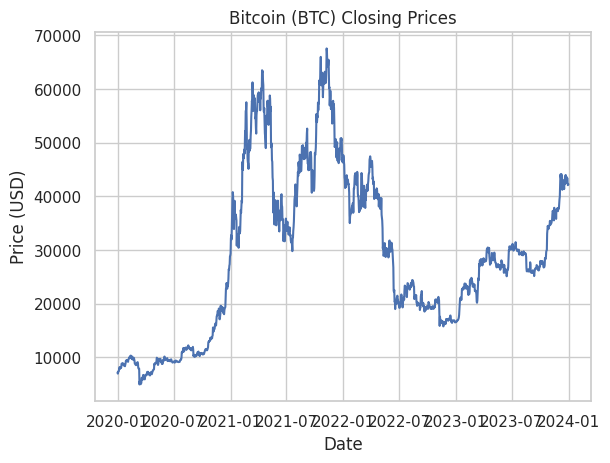

In [ ]:
# Plotting the closing price
plt.plot(data['Close'])
plt.title("Bitcoin (BTC) Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

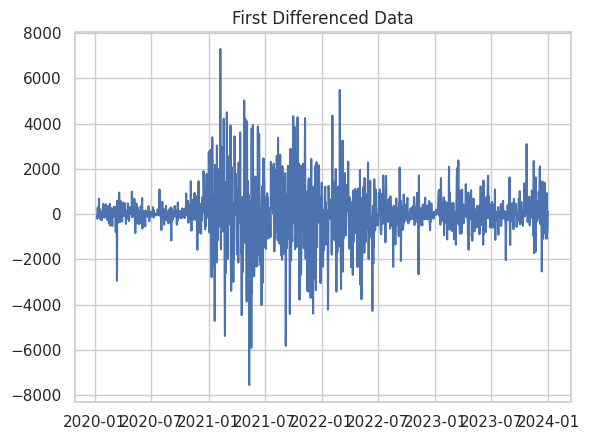

ADF Statistic (Differenced): -11.98556363968322
p-value (Differenced): 3.620076030684206e-22


In [ ]:
# First differencing
data['Differenced'] = data['Close'] - data['Close'].shift(1)

# Drop the NaN value created by differencing
data_diff = data.dropna()

# Plot the differenced data
plt.plot(data_diff['Differenced'])
plt.title('First Differenced Data')
plt.show()

# Perform ADF test on differenced data
adf_result_diff = adfuller(data_diff['Differenced'])
print(f'ADF Statistic (Differenced): {adf_result_diff[0]}')
print(f'p-value (Differenced): {adf_result_diff[1]}')


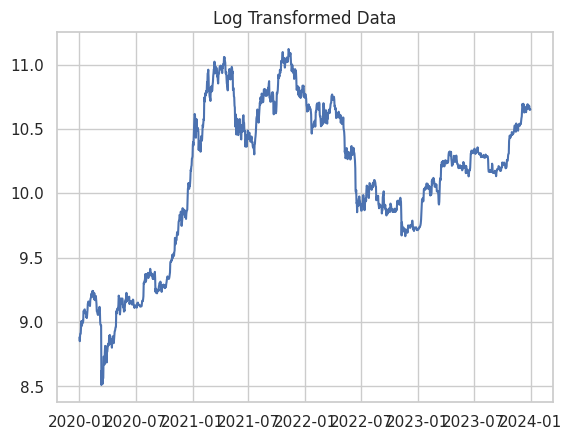

In [ ]:
# Log transformation
data['Log'] = np.log(data['Close'])

# Plot the log-transformed data
plt.plot(data['Log'])
plt.title('Log Transformed Data')
plt.show()

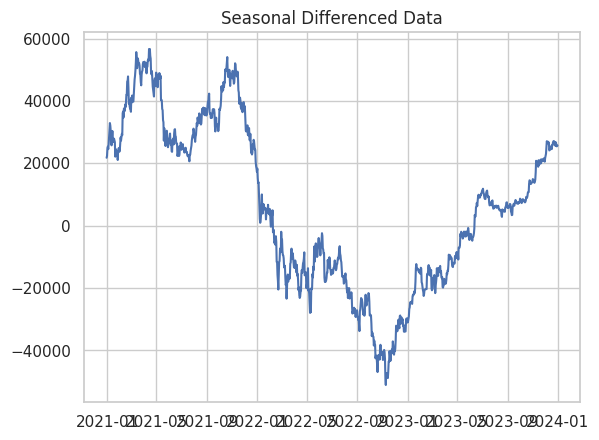

In [ ]:
# Seasonal differencing (assumed period of 365 days for yearly seasonality)
data['Seasonal_Diff'] = data['Close'] - data['Close'].shift(365)

# Drop NaN values
data_seasonal_diff = data.dropna()

# Plot seasonal differenced data
plt.plot(data_seasonal_diff['Seasonal_Diff'])
plt.title('Seasonal Differenced Data')
plt.show()

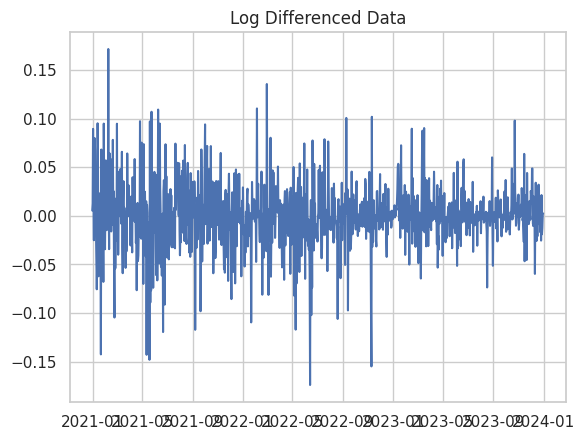

In [ ]:
# First differencing on log-transformed data
data['Log_Diff'] = np.log(data['Close']).diff(1)

# Drop NaN values
data_log_diff = data.dropna()

# Plot the differenced log data
plt.plot(data_log_diff['Log_Diff'])
plt.title('Log Differenced Data')
plt.show()

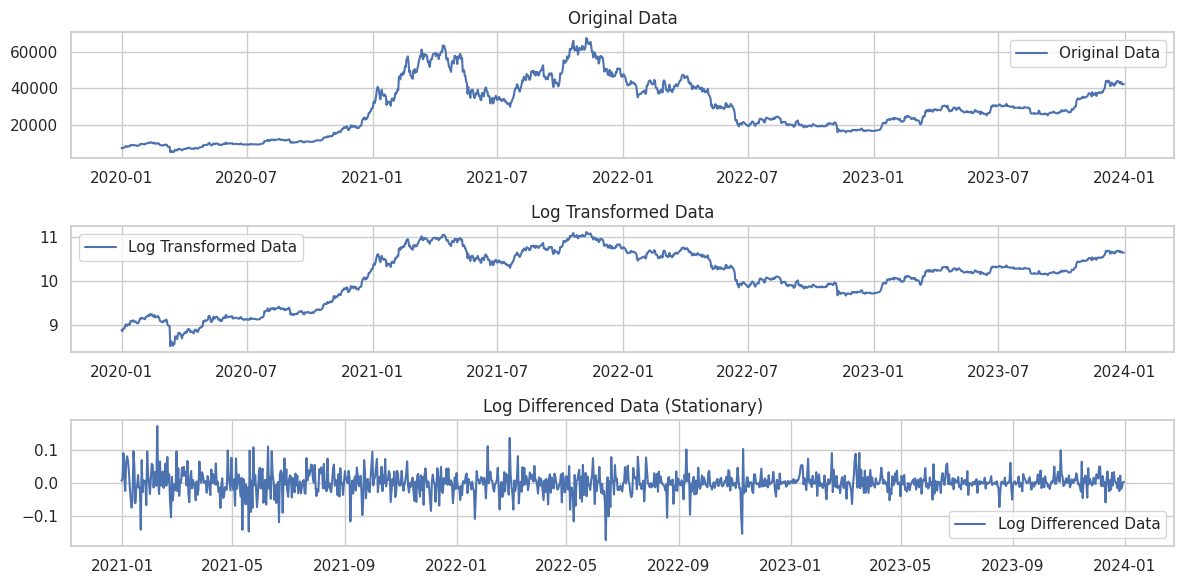

In [ ]:
# Plot the original, log-transformed, and log-differenced data
plt.figure(figsize=(12,6))
plt.subplot(311)
plt.plot(data['Close'], label='Original Data')
plt.title('Original Data')
plt.legend()

plt.subplot(312)
plt.plot(data['Log'], label='Log Transformed Data')
plt.title('Log Transformed Data')
plt.legend()

plt.subplot(313)
plt.plot(data_log_diff['Log_Diff'], label='Log Differenced Data')
plt.title('Log Differenced Data (Stationary)')
plt.legend()

plt.tight_layout()
plt.show()

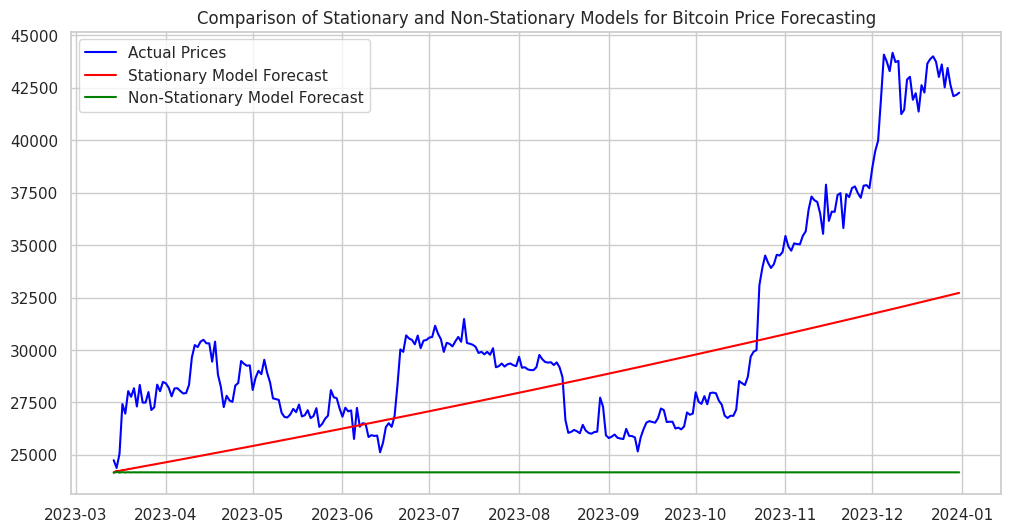

In [ ]:
plt.figure(figsize=(12,6))

# Plot the actual values
plt.plot(test['Close'], label='Actual Prices', color='blue')

# Plot forecasted values from the stationary model
plt.plot(test.index, forecast_stationary_prices, label='Stationary Model Forecast', color='red')

# Plot forecasted values from the non-stationary model
plt.plot(test.index, forecast_non_stationary_prices, label='Non-Stationary Model Forecast', color='green')

plt.title('Comparison of Stationary and Non-Stationary Models for Bitcoin Price Forecasting')
plt.legend()
plt.show()


### Diagnosis

Visual Inspection: The rolling mean and standard deviation plots show both statistics changing significantly over time, indicating non-stationarity


Statistical test include Augmented Dickey-Fuller (ADF) Test. (Baumöhl and Lyócsa)


The ADF test checks if a time series has a unit root (non-stationary)
If the test shows no unit root, the series is stationary


If the test shows a unit root, the series is non-stationary and may need differencing


The ADF test uses an augmented version of the standard Dickey-Fuller test, where lags of the differenced time series are included.This accounts for higher-order autocorrelations in the data.


p-value = 0.409 (> 0.05), indicating non-stationarity in the code


### Damage

The damage caused by non-stationarity becomes clear in the forecasting results.


The non-stationary model (working with raw log-transformed data) performed significantly worse that is\
MAE: 6,430.68  RMSE: 8,242.12

Wheras  the stationary model (using log-differenced data) performed much better\
MAE: 3,573.87 RMSE: 4,511.81


This means the non-stationary model's predictions were off by about 80% more on average!


Non-stationary financial data makes it extremely difficult to assess and manage risk properly. Traditional risk measures like Value at Risk (VaR) assume some level of stationarity in the underlying data. When this assumption is violated, risk models can severely underestimate potential losses


Trading strategies that work well in one period might completely fail in another when dealing with non-stationary data. For example, if we are  running an algorithmic trading system based on historical patterns, for buy n sell signals  non-stationarity means these patterns might suddenly become invalid with false trading signals and  portfolio loss


If we see  the Bitcoin data from our document. The wide swings in price and changing volatility patterns make it difficult for businesses to:
1. Plan  cryptocurrency holdings
2. Set appropriate prices for crypto-based services
3. Manage thei treasury operations effectively


### Directions

Log Transformations helps stabilize variance but doesn't completely solve the stationarity issue.Taking the difference between consecutive values removes trends. The code document  has these two
* Regular differencing (price[t] - price[t-1])
* Seasonal differencing (price[t] - price[t-365])

The successful approach which we  used was log transformation followed by differencing, which:
* Stabilized the variance through log transformation and removed the trends though differencing and hence we got suitable stationary series for ARIMA modelling

Other approaches could include garch volatility estimates ,ARCH models are particularly good at capturing and forecasting volatility clustering - periods where big price changes tend to be followed by other big changes.
